In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
df = pd.read_csv("emission_events_case_study_2.csv")

In [3]:
df.head(5)

,id,rate,duration,quantity,sourceLocation,startTime,endTime,merged_from,event_type,uncertainties
0,40f0c8cc-45e8-4d81-adee-a6253299edad,87.870776,22.266667,1956.589280,A,2024-01-01T02:16:00,2024-01-02T00:32:00,"1, 90, 91, 2",RE,35.148310
1,0938060c-4540-4b58-9f2a-f97210177698,159.222171,0.116667,18.575920,A,2024-01-02T06:50:00,2024-01-02T06:57:00,92,RE,63.688869
2,f1229c64-3eab-4898-b5bf-6f3d7c10a31e,135.593756,33.283333,4513.012183,A,2024-01-02T08:38:00,2024-01-03T17:55:00,"3, 4, 93",RE,54.237502
3,d2d36e71-49f0-4131-ad75-7c498fcf1572,5.279977,3.550000,18.743919,A,2024-01-03T23:33:00,2024-01-04T03:06:00,5,PRE,2.111991
4,71d06e78-fe40-49dc-b397-2be375c3bbf7,44.443410,8.383333,372.583920,A,2024-01-04T12:02:00,2024-01-04T20:25:00,6,PRE,17.777364


In [12]:
# Resolved events 
re_durations =df[df["event_type"] == "RE"]["duration"] 
re_rates = df[df["event_type"] == "RE"]["rate"]
re_rate_unc = df[df["event_type"] == "RE"]["uncertainties"] 
re_quan = df[df["event_type"] == "RE"]["quantity"]
# Partially Resolved Events 
pre_durations = df[df["event_type"] == "PRE"]["duration"]
pre_rates = df[df["event_type"] == "PRE"]["rate"]
pre_quan = df[df["event_type"] == "PRE"]["quantity"]
pre_rate_unc = df[df["event_type"] == "PRE"]["uncertainties"]



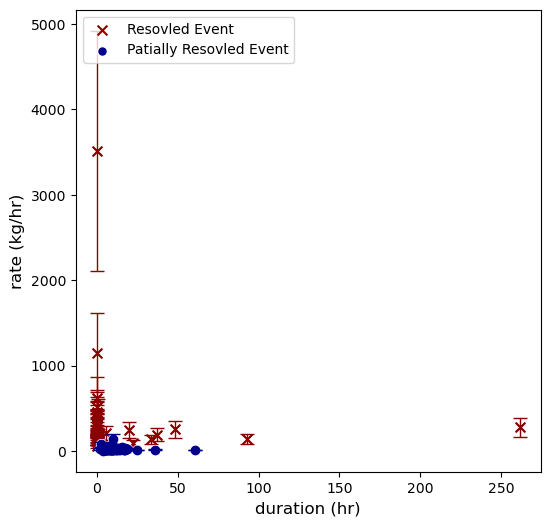

In [7]:
# Create the scatter plot
#plt.style.use('seaborn-darkgrid')
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(re_durations, re_rates, color='darkred', s=50, marker = 'x', zorder=1, label='Resovled Event')
scatter = ax.scatter(pre_durations, pre_rates, color='darkblue', s=50, edgecolor='w', zorder=2, label='Patially Resovled Event')
# Add error bars
error_bars = ax.errorbar(re_durations, re_rates, yerr=re_rate_unc, fmt='x', color='darkred', ecolor='darkred', elinewidth=1, capsize=5, zorder=1)
error_bars = ax.errorbar(pre_durations, pre_rates, yerr=pre_rate_unc, fmt='o', color='darkblue', ecolor='darkblue', elinewidth=1, capsize=5, zorder=2)

plt.xlabel('duration (hr)',  fontsize=12)
plt.ylabel('rate (kg/hr)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.savefig("event_rates_scatter.png",dpi=600)

In [8]:
log_bins = np.logspace(np.log10(min(min(re_durations), min(pre_durations))), 
                       np.log10(max(max(re_durations), max(pre_durations))), 
                       num=30)

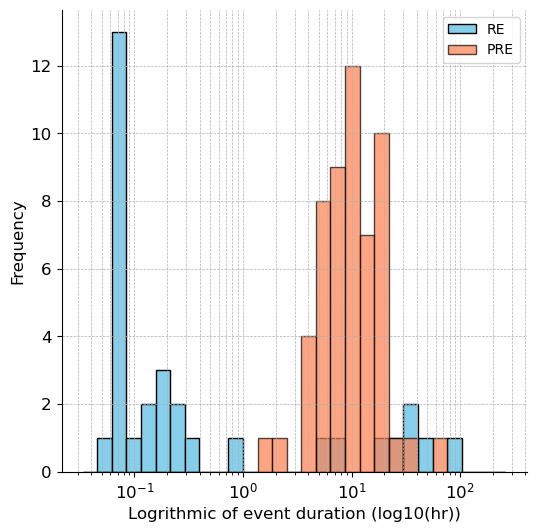

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

# Histogram with customized appearance
ax.hist(re_durations,bins=log_bins, color='skyblue', edgecolor='black', alpha=1, label='RE')
ax.hist(pre_durations, bins=log_bins, color='coral', edgecolor='black', alpha=0.7, label='PRE')
# ax.hist(re_durations, bins = [], color='skyblue', edgecolor='black', alpha=1)
# ax.hist(pre_durations,bins = [], color='coral', edgecolor='black', alpha=0.7)
# Customize the grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xscale('log')
# Customize the ticks and spines
ax.tick_params(axis='both', which='major', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Logrithmic of event duration (log10(hr))', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.legend(loc='upper right', fontsize=10)
# Show the plot
plt.savefig("event_emissions_durations.png",dpi=600)

C:\Users\cookg\AppData\Local\Temp\ipykernel_20636\2437695811.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([re_quan, pre_quan], labels=['Emissions of RE', 'Emissions of PRE'])


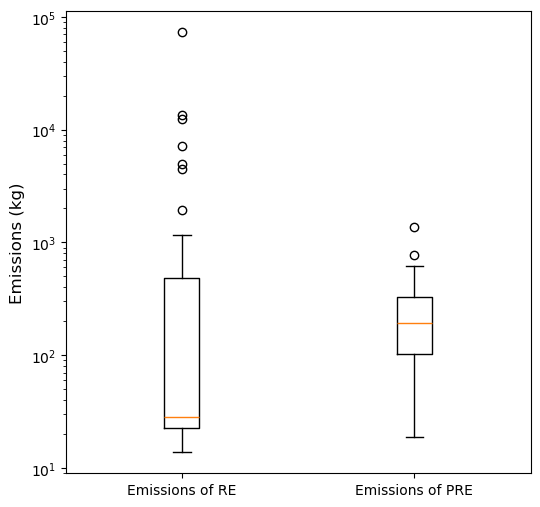

In [13]:
# Creating box plots
plt.figure(figsize=(6, 6))
plt.boxplot([re_quan, pre_quan], labels=['Emissions of RE', 'Emissions of PRE'])
plt.yscale('log')
plt.ylabel('Emissions (kg)',  fontsize=12)
#plt.grid(True)
plt.savefig("event_emissions_boxplots.png",dpi=600)

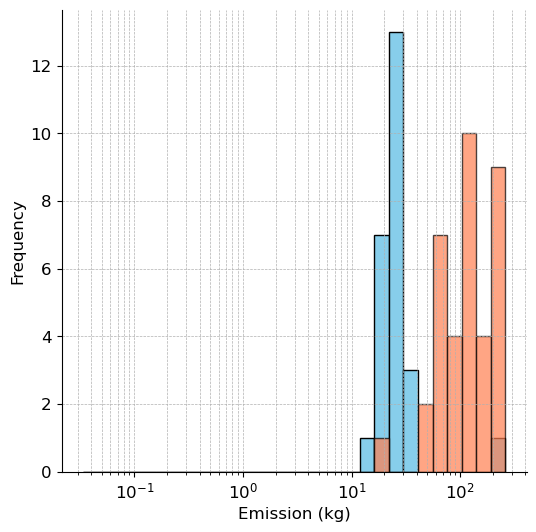

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))

# Histogram with customized appearance
ax.hist(re_quan,bins=log_bins, color='skyblue', edgecolor='black', alpha=1)
ax.hist(pre_quan, bins=log_bins, color='coral', edgecolor='black', alpha=0.7)
# ax.hist(re_quan,bins=30, color='skyblue', edgecolor='black', alpha=1)
# ax.hist(pre_quan, bins=30, color='coral', edgecolor='black', alpha=0.7)
# Customize the grid
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xscale('log')
# Customize the ticks and spines
ax.tick_params(axis='both', which='major', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Emission (kg)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show the plot
plt.savefig("event_emissions_histogram.pdf",dpi=600)

#### Plot emissions from RE, PRE and UE 

In [ ]:
plt.figure(figsize=(15, 5))
categories = [ 'Emissions from PREs','Emissions from UEs', "Total Emissions"]
values = [12752.899311616686, 890185.1218787591, 902938.0211903758]
errors = [[2434.553750186221, 55587.91748871652, 55641.20436057169],
          [8472.495788120596, 80007.72328332221, 80455.07423314195]]
bar_width = 0.55
colors = ['darkcyan', 'darkcyan', 'salmon']
index = np.arange(len(categories))
plt.barh(index, values, xerr=errors, height=bar_width, color=colors , capsize=5)
#plt.ylabel('Categories')
plt.xlabel('Emissions (kg)', fontsize=12)
plt.yticks(index, categories, fontsize=12)
plt.savefig("reconciled_results_case_study_2.png",dpi=600)